# Baseline capacity model / 基准容量模型

Rebuild the original server → rack → pod → facility calculation. Inputs are planning assumptions, with maximum whole-server power from NVIDIA. / 重建原服务器、机架、Pod和设施计算，采用规划假设及NVIDIA整机最大功率。

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image

# Support execution from the repository or notebooks directory.
# 支持从仓库根目录或 notebooks 目录执行。
ROOT = Path.cwd().resolve()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "src").is_dir():
    raise RuntimeError("Start in the repository / 请从仓库目录启动")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


In [2]:
from src.power_model import evaluate
from src.scenarios import load_scenarios
baseline = next(inputs for row, inputs in load_scenarios(ROOT / "data/scenario_parameters.csv") if row["scenario"] == "Baseline")
result = evaluate(baseline)
display(pd.DataFrame([result]).T.rename(columns={0: "Value / 数值"}))

,Value / 数值
facility_capacity_mw,500.000000
server_power_kw,14.300000
gpus_per_server,8.000000
servers_per_rack,4.000000
network_power_kw,1.500000
racks_per_pod,32.000000
pue,1.200000
rack_it_power_kw,58.700000
pod_it_power_mw,1.878400
pod_facility_power_mw,2.254080


## Baseline verification / 基准验证

The default configuration must reproduce 221 pods, 7,072 racks and 226,304 GPUs. This cell intentionally fails if the Baseline CSV row is edited to a different configuration. / 默认配置应复现221个Pod、7,072个机架和226,304块GPU。若修改CSV基准配置，下方原始基准断言可能失败。

In [3]:
assert result["max_pods"] == 221
assert result["total_racks"] == 7072
assert result["total_gpus"] == 226304
assert result["remaining_capacity_mw"] >= 0
print("Original baseline verified / 原始基准验证通过")

Original baseline verified / 原始基准验证通过


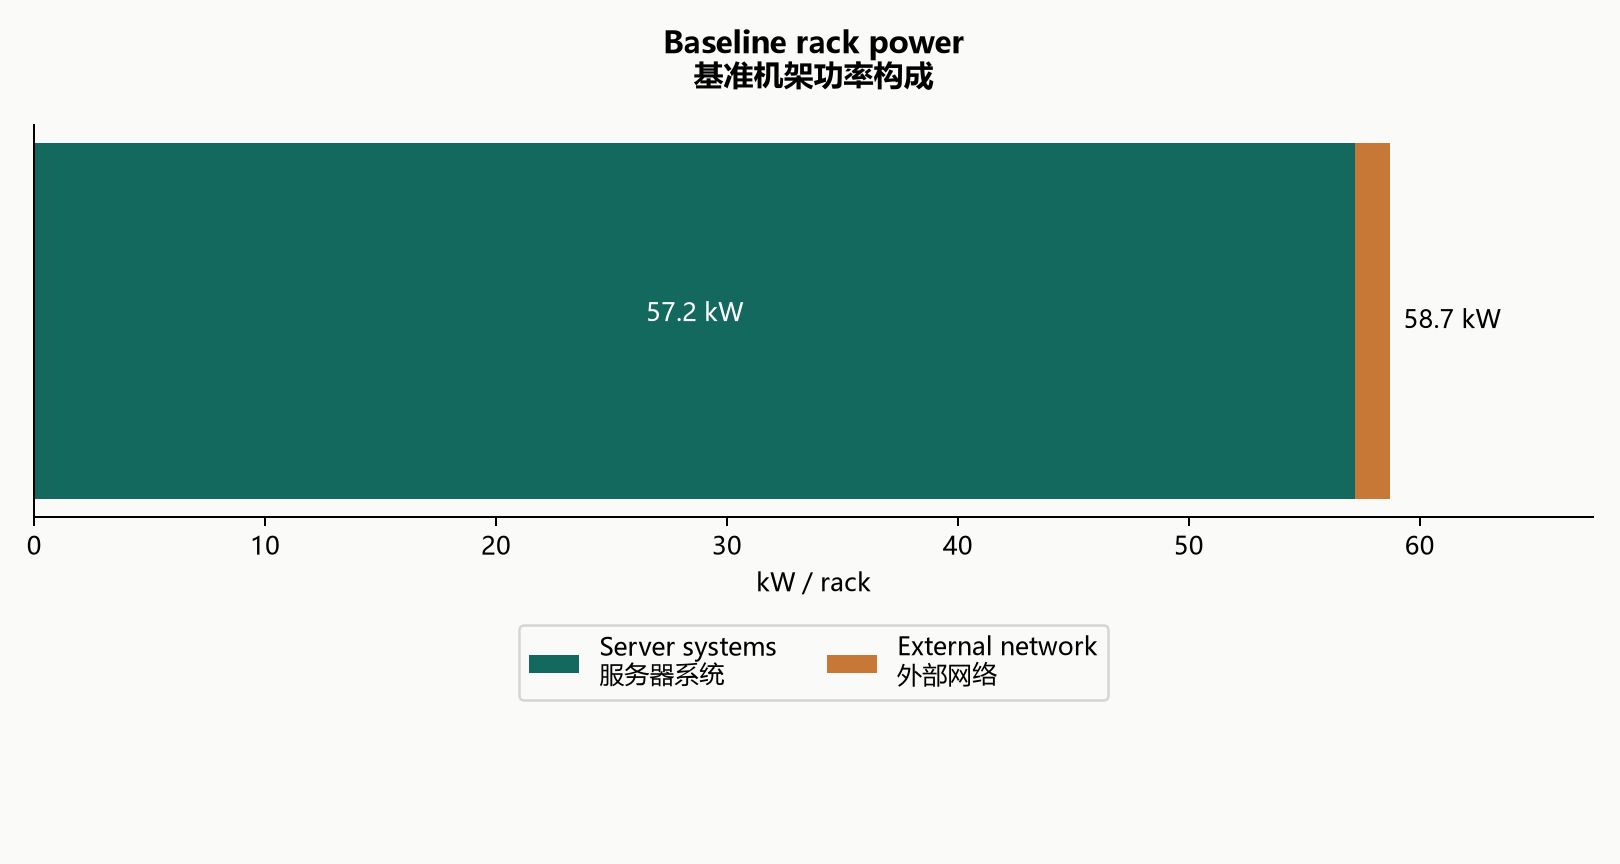

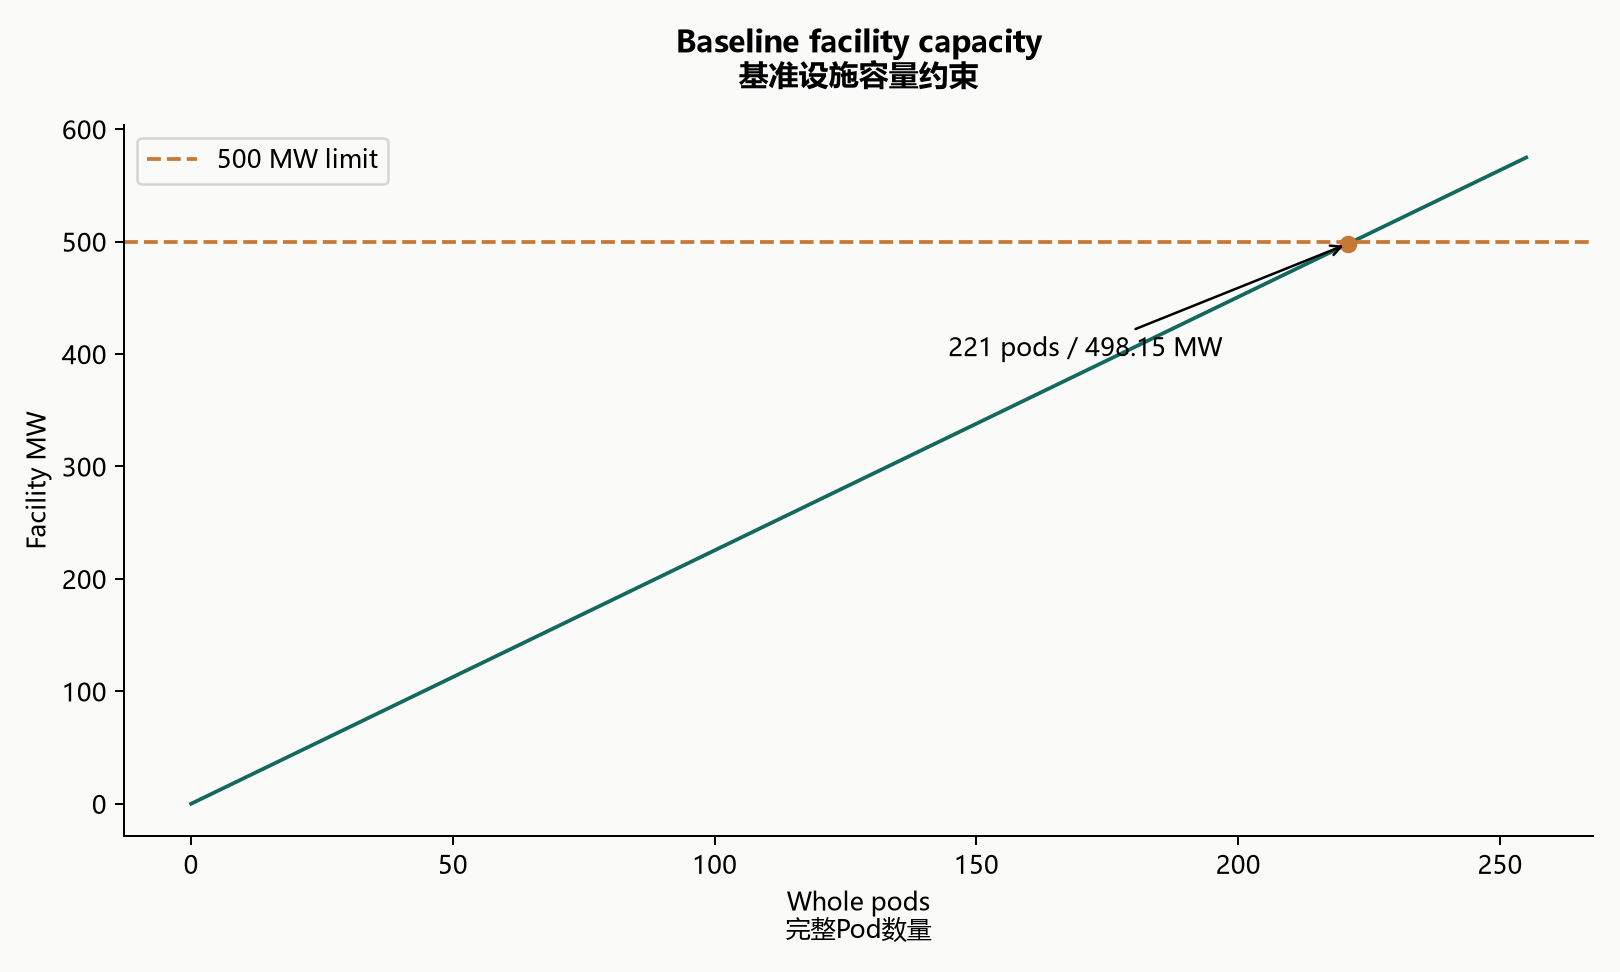

In [4]:
display(Image(filename=str(ROOT / "figures/rack_power_breakdown.png")))
display(Image(filename=str(ROOT / "figures/facility_capacity.png")))

## Interpretation / 结果解释

The remaining 1.84832 MW cannot fit another complete baseline pod. This is an integer-packing remainder, not a deliberate safety reserve. The 99.630336% capacity utilization describes facility power allocation, not GPU compute utilization. / 剩余1.84832 MW不足以容纳另一个完整基准Pod。这是整数装填余量，并非主动设置的安全预留。99.630336%是设施功率容量利用率，不是GPU计算利用率。

Figures display the shipped analysis. Regenerate with `python run_analysis.py` after changing inputs. / 图表展示随仓库提供的分析，修改输入后请运行入口重新生成。